In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_excel("ó/content/chocolate cleaned data.xlsx")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sales Person   299 non-null    object 
 1   Geography      299 non-null    object 
 2   Product        299 non-null    object 
 3   Amount         299 non-null    int64  
 4   Units          299 non-null    int64  
 5   cost per unit  299 non-null    int64  
 6   Cost           299 non-null    int64  
 7   Profit         299 non-null    int64  
 8   profit %       299 non-null    float64
dtypes: float64(1), int64(5), object(3)
memory usage: 21.2+ KB


In [ ]:
df.columns

Index(['Sales Person', 'Geography', 'Product', 'Amount', 'Units',
       'cost per unit', 'Cost', 'Profit', 'profit %'],
      dtype='object')

###DATA CLEANING


In [ ]:
df.columns

Index(['Sales Person', 'Geography', 'Product', 'Amount', 'Units',
       'cost per unit', 'Cost', 'Profit', 'profit %'],
      dtype='object')

In [ ]:
df.describe()

,Amount,Units,cost per unit,Cost,Profit,profit %
count,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000
mean,4150.063545,152.257525,9.481605,1467.371237,3264.70903,-0.332542
std,3120.856174,118.293276,3.460539,1365.626670,2830.70598,5.324265
min,21.000000,0.000000,3.000000,0.000000,5.00000,-69.320000
25%,1676.500000,54.000000,6.000000,487.000000,1016.00000,0.160000
50%,3472.000000,123.000000,9.000000,1082.000000,2452.00000,0.640000
75%,6212.500000,222.000000,12.000000,2018.500000,4872.00000,0.890000
max,16184.000000,525.000000,17.000000,8683.000000,15841.00000,1.000000


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sales Person   299 non-null    object 
 1   Geography      299 non-null    object 
 2   Product        299 non-null    object 
 3   Amount         299 non-null    int64  
 4   Units          299 non-null    int64  
 5   cost per unit  299 non-null    int64  
 6   Cost           299 non-null    int64  
 7   Profit         299 non-null    int64  
 8   profit %       299 non-null    float64
dtypes: float64(1), int64(5), object(3)
memory usage: 21.2+ KB


In [ ]:
df.columns

Index(['Sales Person', 'Geography', 'Product', 'Amount', 'Units',
       'cost per unit', 'Cost', 'Profit', 'profit %'],
      dtype='object')

In [ ]:
df['Geography'].unique()

array(['New Zealand', 'USA', 'Canada', 'UK', 'Australia', 'India'],
      dtype=object)

In [ ]:
person=df.groupby('Sales Person').sum()

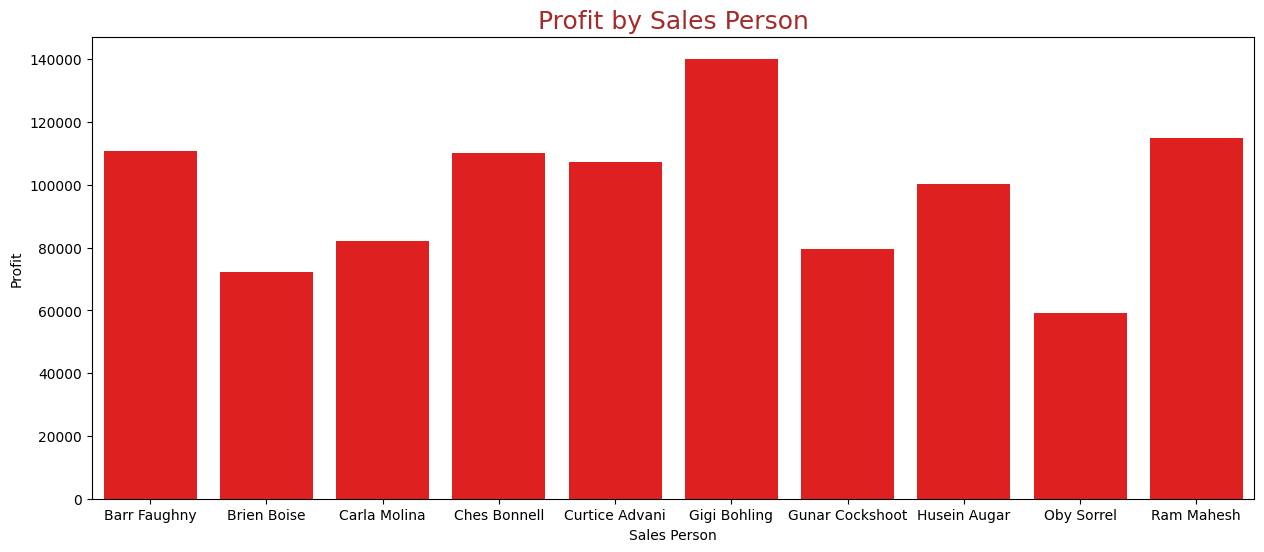

In [ ]:
plt.figure(figsize=(15,6))
sns.barplot(person['Profit'],color='red')
plt.title('Profit by Sales Person',size=18,color='brown')
plt.show()

In [ ]:
#maximun number of units sold and the name of product by each geography
df1=df.groupby('Geography').sum()

In [ ]:

df1['Cost'].corr(df1['Profit'])

np.float64(-0.21314294969140193)

<Axes: ylabel='Profit'>

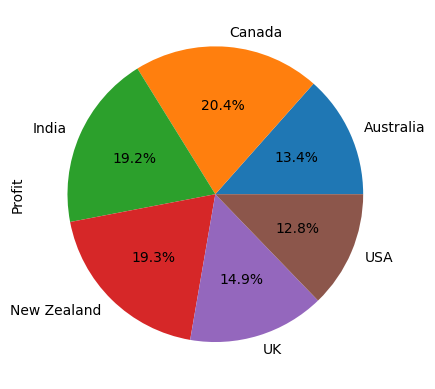

In [ ]:
df1['Profit'].plot(kind='pie',autopct='%0.1f%%')

In [ ]:
df['Product'].unique()

array(['70% Dark Bites', 'Choco Coated Almonds', 'Almond Choco',
       'Drinking Coco', 'White Choc', 'Peanut Butter Cubes',
       'Smooth Sliky Salty', 'After Nines', '50% Dark Bites', 'Eclairs',
       'Mint Chip Choco', 'Milk Bars', 'Manuka Honey Choco',
       'Orange Choco', 'Fruit & Nut Bars', '99% Dark & Pure',
       'Raspberry Choco', '85% Dark Bars', 'Organic Choco Syrup',
       'Caramel Stuffed Bars', 'Spicy Special Slims',
       "Baker's Choco Chips"], dtype=object)

In [ ]:
df2=df.groupby('Product').sum()[['Profit']]

In [ ]:
df2.head(2)

,Profit
Product,
50% Dark Bites,26549
70% Dark Bites,47557


In [ ]:
import sqlite3
conn=sqlite3.connect(':memory:')
df.to_sql('df',conn,index=False)

299

In [ ]:
df2=pd.read_sql_query('''select product,sum(Profit) as "profit" from df
group by Product
order by ''',conn )

Text(0, 0.5, 'Product')

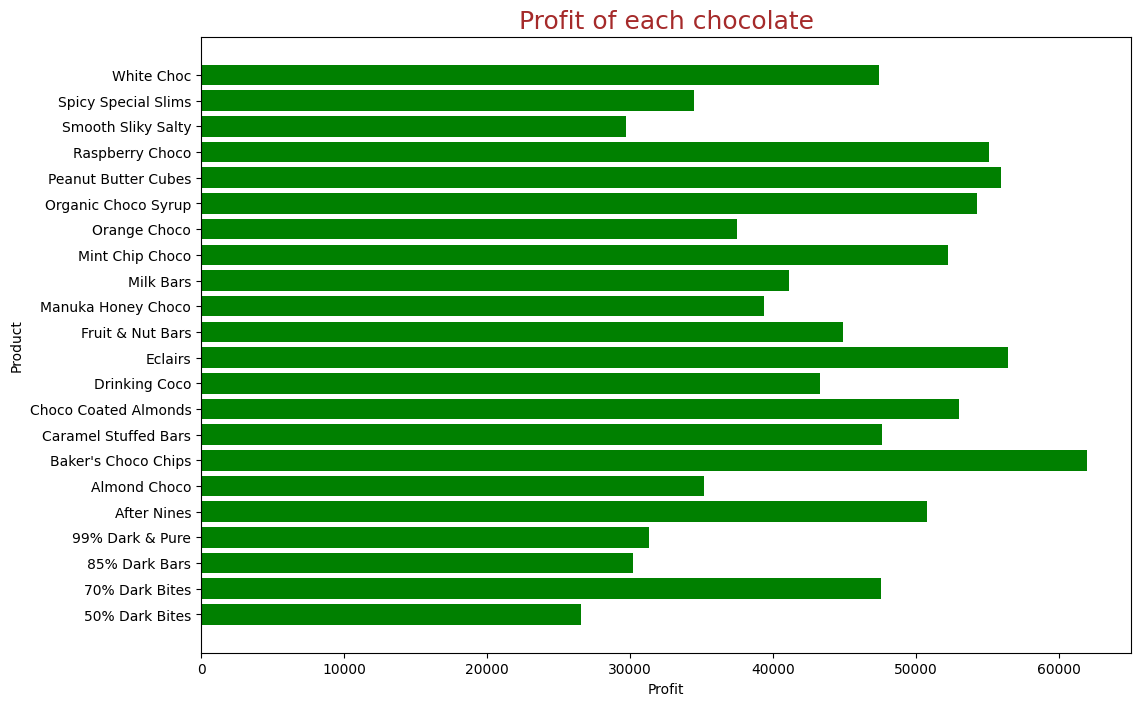

In [ ]:
plt.figure(figsize = (12,8))
plt.barh(df2['Product'],df2['profit'],color='green')
plt.title('Profit of each chocolate',size=18,color='brown')
plt.xlabel('Profit')
plt.ylabel('Product')